In [1]:
import pandas as pd
import numpy as np

In [5]:
df_JSAI=pd.read_csv("C:\\Users\\takic\\OneDrive\\デスクトップ\\修論関係(人狼知能)\\役職推定_GitHub\\data\\2025spring\\all_feature_table_2025sp17_with_talks.csv")
df_INLG=pd.read_csv("C:\\Users\\takic\\OneDrive\\デスクトップ\\修論関係(人狼知能)\\役職推定_GitHub\\data\\2025summer\\all_feature_table_2025summer_with_talks2.csv")

In [ ]:
df_JSAI_day1_file = df_JSAI[df_JSAI['attack_id'].isnull()]["source_file"].unique()
len(df_JSAI_day1_file)
df_JSAI_day1 = df_JSAI[df_JSAI['source_file'].isin(df_JSAI_day1_file)]
df_JSAI_day2=df_JSAI[~df_JSAI['source_file'].isin(df_JSAI_day1_file)]

print("JSAI day1:", len(df_JSAI_day1))
print("JSAI day2:", len(df_JSAI_day2))

JSAI day1: 390
JSAI day2: 670


In [ ]:
df_JSAI_day1.

,,attack_id,True_Div_recepient_id_1,True_Div_recepient_id_2,day1_vote_id,day2_vote_id,ReqDiscuss,ReqListen,Req(CO),Tally,Admiration,...,Dis_id_contradiction,Dis_id_XOR,Dis_id_difficult,Dis_id_confused,Dis_id_Sus,Dis_id_Vote,Dis_id_Pers,Dis_id_Mt,Dis_id_IF,Dis_id_Fact
role,has_day2,,,,,,,,,,,,,,,,,,,,,
POSSESSED,True,2.597015,NaN,NaN,3.067308,NaN,4.320755,0.424528,0.075472,0.0,0.000000,...,0.166667,0.0,0.125000,0.291667,1.291667,0.333333,2.083333,3.500000,0.000000,0.208333
SEER,True,2.597015,3.198113,3.184211,2.952830,NaN,4.207547,0.547170,0.056604,0.0,0.000000,...,0.111111,0.0,0.407407,0.222222,1.518519,0.555556,1.111111,2.222222,0.000000,0.185185
VILLAGER,True,2.597015,NaN,NaN,2.966825,NaN,5.306604,0.594340,0.051887,0.0,0.018868,...,0.040816,0.0,0.285714,0.102041,1.979592,0.469388,1.734694,2.428571,0.081633,0.326531
WEREWOLF,True,2.597015,NaN,NaN,2.896226,NaN,4.660377,0.783019,0.066038,0.0,0.000000,...,0.111111,0.0,0.444444,0.185185,2.037037,0.444444,2.666667,4.222222,0.037037,0.185185


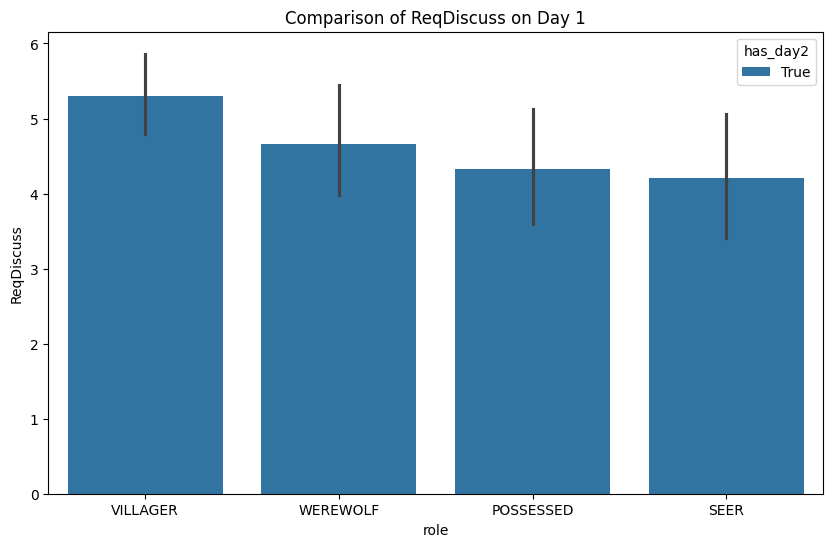

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 2日目が存在する試合（source_file）を特定
day2_exists_files = df_JSAI[df_JSAI['day'] == 2]['source_file'].unique()

# 2. 全レコードに「2日目がある試合かどうか」のフラグを付与
df_JSAI['has_day2'] = df_JSAI['source_file'].isin(day2_exists_files)

# 3. 比較のため「1日目のデータのみ」を抽出
# ※挙動の差を純粋に比較するため、条件を1日目に統一します
df_day1_only = df_JSAI[df_JSAI['day'] == 1].copy()

# 4. 集計対象とする数値特徴量を選択
# ID系やdayなどの集計に適さないカラムを除外
exclude_cols = ['id', 'day', 'exec_id', 'seer_co_order', 'seer_co_num', 'target_total_votes']
numeric_cols = df_day1_only.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

# 5. 役職(role) と 2日目の有無(has_day2) ごとに特徴量の平均を算出
grouped_res = df_day1_only.groupby(['role', 'has_day2'])[feature_cols].mean()

# 結果の確認（最初の数行）
display(grouped_res.head(10))

# 6. 特定の特徴量について可視化（例：発話回数などの差を見る）
# 特徴量のリストから、差が大きそうなものをピックアップして描画
sample_feature = 'ReqDiscuss'  # 例として「相談リクエスト」の回数
plt.figure(figsize=(10, 6))
sns.barplot(data=df_day1_only, x='role', y=sample_feature, hue='has_day2')
plt.title(f'Comparison of {sample_feature} on Day 1')
plt.show()